In [ ]:
# CM3 eval for historical SST trend

Based on https://github.com/COSIMA/cosima-recipes/blob/8a0205ec0c85d2d08fe94fb3acd901b18f392c37/Cooking-Lessons-101-Tutorials/Apply_function_to_every_gridpoint.ipynb

In [1]:
#parameters

### USER EDIT start
esm_file= '/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/'
#'/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json'
plotfolder='/g/data/k10/qo9901/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/
Plot folder path:  /g/data/k10/qo9901/


In [15]:
cm2_dir =  '/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/'

In [2]:
cd /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/2017/ocean/


/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/2017/ocean


In [3]:
ls

access-cm3.mom6.2d.Heat_PmE.1mon.mean.2017.nc
access-cm3.mom6.2d.Rd_dx.1mon.mean.2017.nc
access-cm3.mom6.2d.SSH.1mon.mean.2017.nc
access-cm3.mom6.2d.SSU.1mon.mean.2017.nc
access-cm3.mom6.2d.SSV.1mon.mean.2017.nc
access-cm3.mom6.2d.T_adx_2d.1mon.mean.2017.nc
access-cm3.mom6.2d.T_ady_2d.1mon.mean.2017.nc
access-cm3.mom6.2d.T_diffx_2d.1mon.mean.2017.nc
access-cm3.mom6.2d.T_diffy_2d.1mon.mean.2017.nc
access-cm3.mom6.2d.evs.1mon.mean.2017.nc
access-cm3.mom6.2d.ficeberg.1mon.mean.2017.nc
access-cm3.mom6.2d.friver.1mon.mean.2017.nc
access-cm3.mom6.2d.fsitherm.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_added.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_cond.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_evap.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_fprec.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_frunoff.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_lprec.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_lrunoff.1mon.mean.2017.nc
access-cm3.mom6.2d.heat_content_vprec

In [4]:
import numpy as np

from dask.distributed import Client

import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg

import matplotlib.pyplot as plt
import cmocean as cm
import scipy

In [77]:

client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42577 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/42577/status,
Dashboard: /proxy/42577/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42095,Workers: 0
Dashboard: /proxy/42577/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33929,Total threads: 1
Dashboard: /proxy/37813/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:39309,


In [6]:
## calculate sst trend over years of exp
sst_cm3 = xr.open_mfdataset(esm_file + '*/ocean/access-cm3.mom6.2d.tos.1mon.mean.*.nc',\
                        chunks={'time':-1,  'xh':60})

/jobfs/153924505.gadi-pbs/ipykernel_1556061/3493891863.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  sst_cm3 = xr.open_mfdataset(esm_file + '*/ocean/access-cm3.mom6.2d.tos.1mon.mean.*.nc',\
/jobfs/153924505.gadi-pbs/ipykernel_1556061/3493891863.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 

In [7]:
sst_cm3 = sst_cm3.sel(time = slice('1981','2014')).chunk({'time':-1})

In [60]:
sst_cm3

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 408, yh: 1142, xh: 1440, nv: 2)
Coordinates:
  * time        (time) datetime64[ns] 3kB 1981-01-16T12:00:00 ... 2014-12-16T...
  * nv          (nv) float64 16B 1.0 2.0
  * yh          (yh) float64 9kB -80.94 -80.87 -80.81 ... 89.74 89.84 89.95
  * xh          (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Data variables:
    tos         (time, yh, xh) float32 3GB dask.array<chunksize=(408, 1142, 60), meta=np.ndarray>
    average_DT  (time) timedelta64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    average_T1  (time) datetime64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    average_T2  (time) datetime64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    time_bnds   (time, nv) datetime64[ns] 7kB dask.array<chunksize=(408, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: access-cm3
    associated_files:  areacello: access-cm3.mom6.h.static.nc
    grid_type:         regular
    grid_tile:         N/A

In [68]:
import glob

In [83]:
# cm2 for same spinup from cold start time period
Filelist = sorted(
    sum(
        [glob.glob(os.path.join(cm2_dir, 'ocn', f'ocean-2d-surface_pot_temp-1-monthly-mean-ym_{yr:04}_*.nc')) for yr in range(1, 35)],
        []
    )
)

# Open as a single dataset
sst_cm2 = xr.open_mfdataset(
    Filelist,
    combine='by_coords',
    chunks={'time': -1, 'xt_ocean': 60}).chunk({'time':-1})

/jobfs/153924505.gadi-pbs/ipykernel_1556061/1304805723.py:12: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  sst_cm2 = xr.open_mfdataset(
/jobfs/153924505.gadi-pbs/ipykernel_1556061/1304805723.py:12: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  sst_cm2 = xr.open_mfdata

In [28]:
def get_trend(time, timeseries):
    '''Calculate the trend through a timeseries using scipy.stats.linregress, 
    and return just the slope and the p value as an array, for the purposes of 
    demonstrating xarray.apply_ufunc

    Inputs:
        time: np.ndarray
            the times or x values of whatever the slope will go through
        timeseries: np.ndarray
            the data to calculate the slope of

    Outputs:
        stats: np.ndarray
            1st element is the trend in timeseries
            2nd element is the p value of this trend, indicating the significance
            They're lumped together into one variable, a) so .load() can be called 
            on both at once, and b) to demonstrate some of the nuance in xr.apply_ufunc
            when using it for more complicated applications
    '''

    slope, intercept, r, p, se = scipy.stats.linregress(time, timeseries)
    return np.array((slope, p)) # Combine into one array because it's easier to load in one go

Define a timeseries for the linear regression to work (because scipy doesn't like datetimes).

Note: This line is specific to the function being applied - in this instance, we want to apply scipy.stats.linregress, and it needs a timeseries of x values so we make it one

In [53]:
def calc_sst_trend(sst,temp_var_str,freq):
    '''
    freq = monthly = 12, daily = 365
    '''
    years_since_start = xr.DataArray(np.arange(sst.time.shape[0])/freq, # changed from prev because now daily
                                 dims=('time',),
                                 coords={'time': sst.time})

    # Pass data through to the `xarray.apply_ufunc`
    stats = xr.apply_ufunc(get_trend,                               # function being used
                           years_since_start,                       # Argument 1 for function
                           sst[temp_var_str],                              # Argument 2 for function
                           input_core_dims=(('time',), ('time',)),  # Dimensions the function needs for each argument
                           output_core_dims=(('stat_type',),),      # Dimensions of each output from the function
                           dask_gufunc_kwargs = {
                            "output_sizes": {'stat_type': 2},       # The new dimension will have size 2
                           },
                           vectorize=True,                          # The function needs to only have one lat and lon at a time
                           dask = 'parallelized',                   # Dask is fine, but the function can't handle it so apply_ufunc needs to
                           )
    stats.load()
    
    # Put data back into some more useful variable names
    sst_trend = stats.sel(stat_type=0)
    p_value = stats.sel(stat_type=1)
    
    if sst.isel(time = 0)[temp_var_str].size > 1e6: 
        if temp_var_str == 'tos':
            geolon_t = xr.open_mfdataset('/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/1981/ocean/access-cm3.mom6.h.static.nc').geolon
            geolat_t = xr.open_mfdataset('/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/1981/ocean/access-cm3.mom6.h.static.nc').geolat
        else:
            geolat_t = xr.open_mfdataset('/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/ocean-2d-geolat_t.nc').geolat_t
            geolon_t = xr.open_mfdataset('/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/ocean-2d-geolon_t.nc').geolon_t

    else:
        geolon_t = xr.open_dataset("/home/561/qo9901/access-om2/old/1deg_esm1p5_forc_atm/archive/output000/ocean/ocean-2d-geolon_t.nc").geolon_t
        geolat_t = xr.open_dataset("/home/561/qo9901/access-om2/old/1deg_esm1p5_forc_atm/archive/output000/ocean/ocean-2d-geolat_t.nc").geolat_t

    sst_trend = sst_trend.assign_coords({"geolon_t": geolon_t, "geolat_t": geolat_t})
    p_value = p_value.assign_coords({"geolon_t": geolon_t, "geolat_t": geolat_t})
    
    return sst_trend, p_value

In [32]:
sst_trend_cm3_monthly, p_value_cm3_monthly = calc_sst_trend(sst_cm3,'tos',12)

/jobfs/153924505.gadi-pbs/ipykernel_1556061/3791691906.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = scipy.stats.linregress(time, timeseries)
/jobfs/153924505.gadi-pbs/ipykernel_1556061/879542736.py:28: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  geolon_t = xr.open_mfdataset('/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/archive/1981/ocean/access-cm3.mom6.h.static.nc').geolon
/jobfs/153924505.gadi-pbs/ipykernel_1556061/879542736.py:29: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this war

In [86]:
sst_trend_cm2_monthly, p_value_cm2_monthly = calc_sst_trend(sst_cm2,'surface_pot_temp',12)

/jobfs/153924505.gadi-pbs/ipykernel_1556061/3791691906.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = scipy.stats.linregress(time, timeseries)
/jobfs/153924505.gadi-pbs/ipykernel_1556061/474703673.py:32: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  geolat_t = xr.open_mfdataset('/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/ocean-2d-geolat_t.nc').geolat_t
/jobfs/153924505.gadi-pbs/ipykernel_1556061/474703673.py:33: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  geolon_t = x

In [48]:
## compare to ESM1.5

In [49]:
esm1p5_dir = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r6i1p1f1/Omon/'

In [50]:
# temp compare to ESM output
esm_temp = xr.open_mfdataset(esm1p5_dir + 'thetao/gn/latest/thetao_Omon_ACCESS-ESM1-5_*.nc')

# get om2 coordinates
expt_dir = '/scratch/if69/qo9901/access-om2/archive/1deg_esm1p5_hist_atm-b6610589/'
temp = xr.open_mfdataset(expt_dir+ '/output000/ocean/ocean-3d-pot_temp-1-monthly-mean-ym_*.nc').pot_temp

esm_temp = esm_temp.rename({'j':'yt_ocean','i':'xt_ocean','lev':'st_ocean'}).assign_coords({'yt_ocean':temp.yt_ocean, 'xt_ocean':temp.xt_ocean})

/jobfs/153924505.gadi-pbs/ipykernel_1556061/3207069961.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  temp = xr.open_mfdataset(expt_dir+ '/output000/ocean/ocean-3d-pot_temp-1-monthly-mean-ym_*.nc').pot_temp


In [51]:
# monthly esm trend
esm_tos_monthly = esm_temp.sel(time = slice('1981','2014')).isel(st_ocean = 0).chunk({'time':-1,  'xt_ocean':60})

In [54]:
sst_trend_esm_monthly, p_value_esm_monthly = calc_sst_trend(esm_tos_monthly,'thetao',12)

/jobfs/153924505.gadi-pbs/ipykernel_1556061/3791691906.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, p, se = scipy.stats.linregress(time, timeseries)


In [55]:
def plotting_trend(sst_trend, p_value, ax, title):
    #ax = plt.axes(projection=ccrs.Robinson())
    ## all subplots have to have projection first
    print('not loaded')
    data = sst_trend.values
    
    # Extract the data and coordinates
    lon = sst_trend.geolon_t.values
    lat = sst_trend.geolat_t.values
    
    print('loaded')
    # Mask everything where any input is NaN
    mask = np.isnan(data) | np.isnan(lat) | np.isnan(lon)
    data_masked = np.ma.masked_array(data, mask=mask)
    print('mask')
    # Plot using pcolor
    '''
    mesh = ax.pcolormesh(
        lon,
        lat,
        data_masked,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.balance,
        shading='auto',
        vmax = 0.1, 
        vmin = -0.1,
            rasterized=True,
    )
    '''
    mesh = ax.scatter(
        lon,
        lat,
        c=data,
        s=1,
        cmap=cmocean.cm.balance,
        transform=ccrs.PlateCarree(),
        vmin=-0.1,
        vmax=0.1,
    )
    print('mesh')
    ##ax.coastlines(resolution="50m")
    #ax.gridlines(draw_labels=False)
    
    # Add colorbar
    cbar = plt.colorbar(mesh, ax=ax, extend='both',shrink = 0.5)
    cbar.set_label('°C/yr')
    
    ax.contourf(p_value.geolon_t, p_value.geolat_t, p_value,
                 levels=(0, 0.05),
                 colors='None',
                 hatches=('...',),
                 transform=ccrs.PlateCarree())
                 

    ax.set_title(title)
    return

In [56]:
sst_trend_cm3_monthly.load()
p_value_cm3_monthly.load()

<xarray.DataArray (yh: 1142, xh: 1440)> Size: 13MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * yh        (yh) float64 9kB -80.94 -80.87 -80.81 -80.74 ... 89.74 89.84 89.95
  * xh        (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
    geolon_t  (yh, xh) float32 7MB nan nan nan nan nan ... 80.0 80.0 80.0 80.0
    geolat_t  (yh, xh) float32 7MB nan nan nan nan ... 65.37 65.26 65.16 65.05

In [57]:
sst_trend_esm_monthly.load()
p_value_esm_monthly.load()

<xarray.DataArray (yt_ocean: 300, xt_ocean: 360)> Size: 864kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    st_ocean   float64 8B 5.0
    latitude   (yt_ocean, xt_ocean) float64 864kB -77.88 -77.88 ... 65.63 65.21
    longitude  (yt_ocean, xt_ocean) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
  * yt_ocean   (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean   (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
    geolon_t   (yt_ocean, xt_ocean) float32 432kB nan nan nan ... 79.97 79.99
    geolat_t   (yt_ocean, xt_ocean) float32 432kB nan nan nan ... 65.63 65.21

In [58]:
import cmocean
import cartopy.crs as ccrs

not loaded
loaded
mask
mesh
not loaded
loaded
mask
mesh
not loaded
loaded
mask
mesh


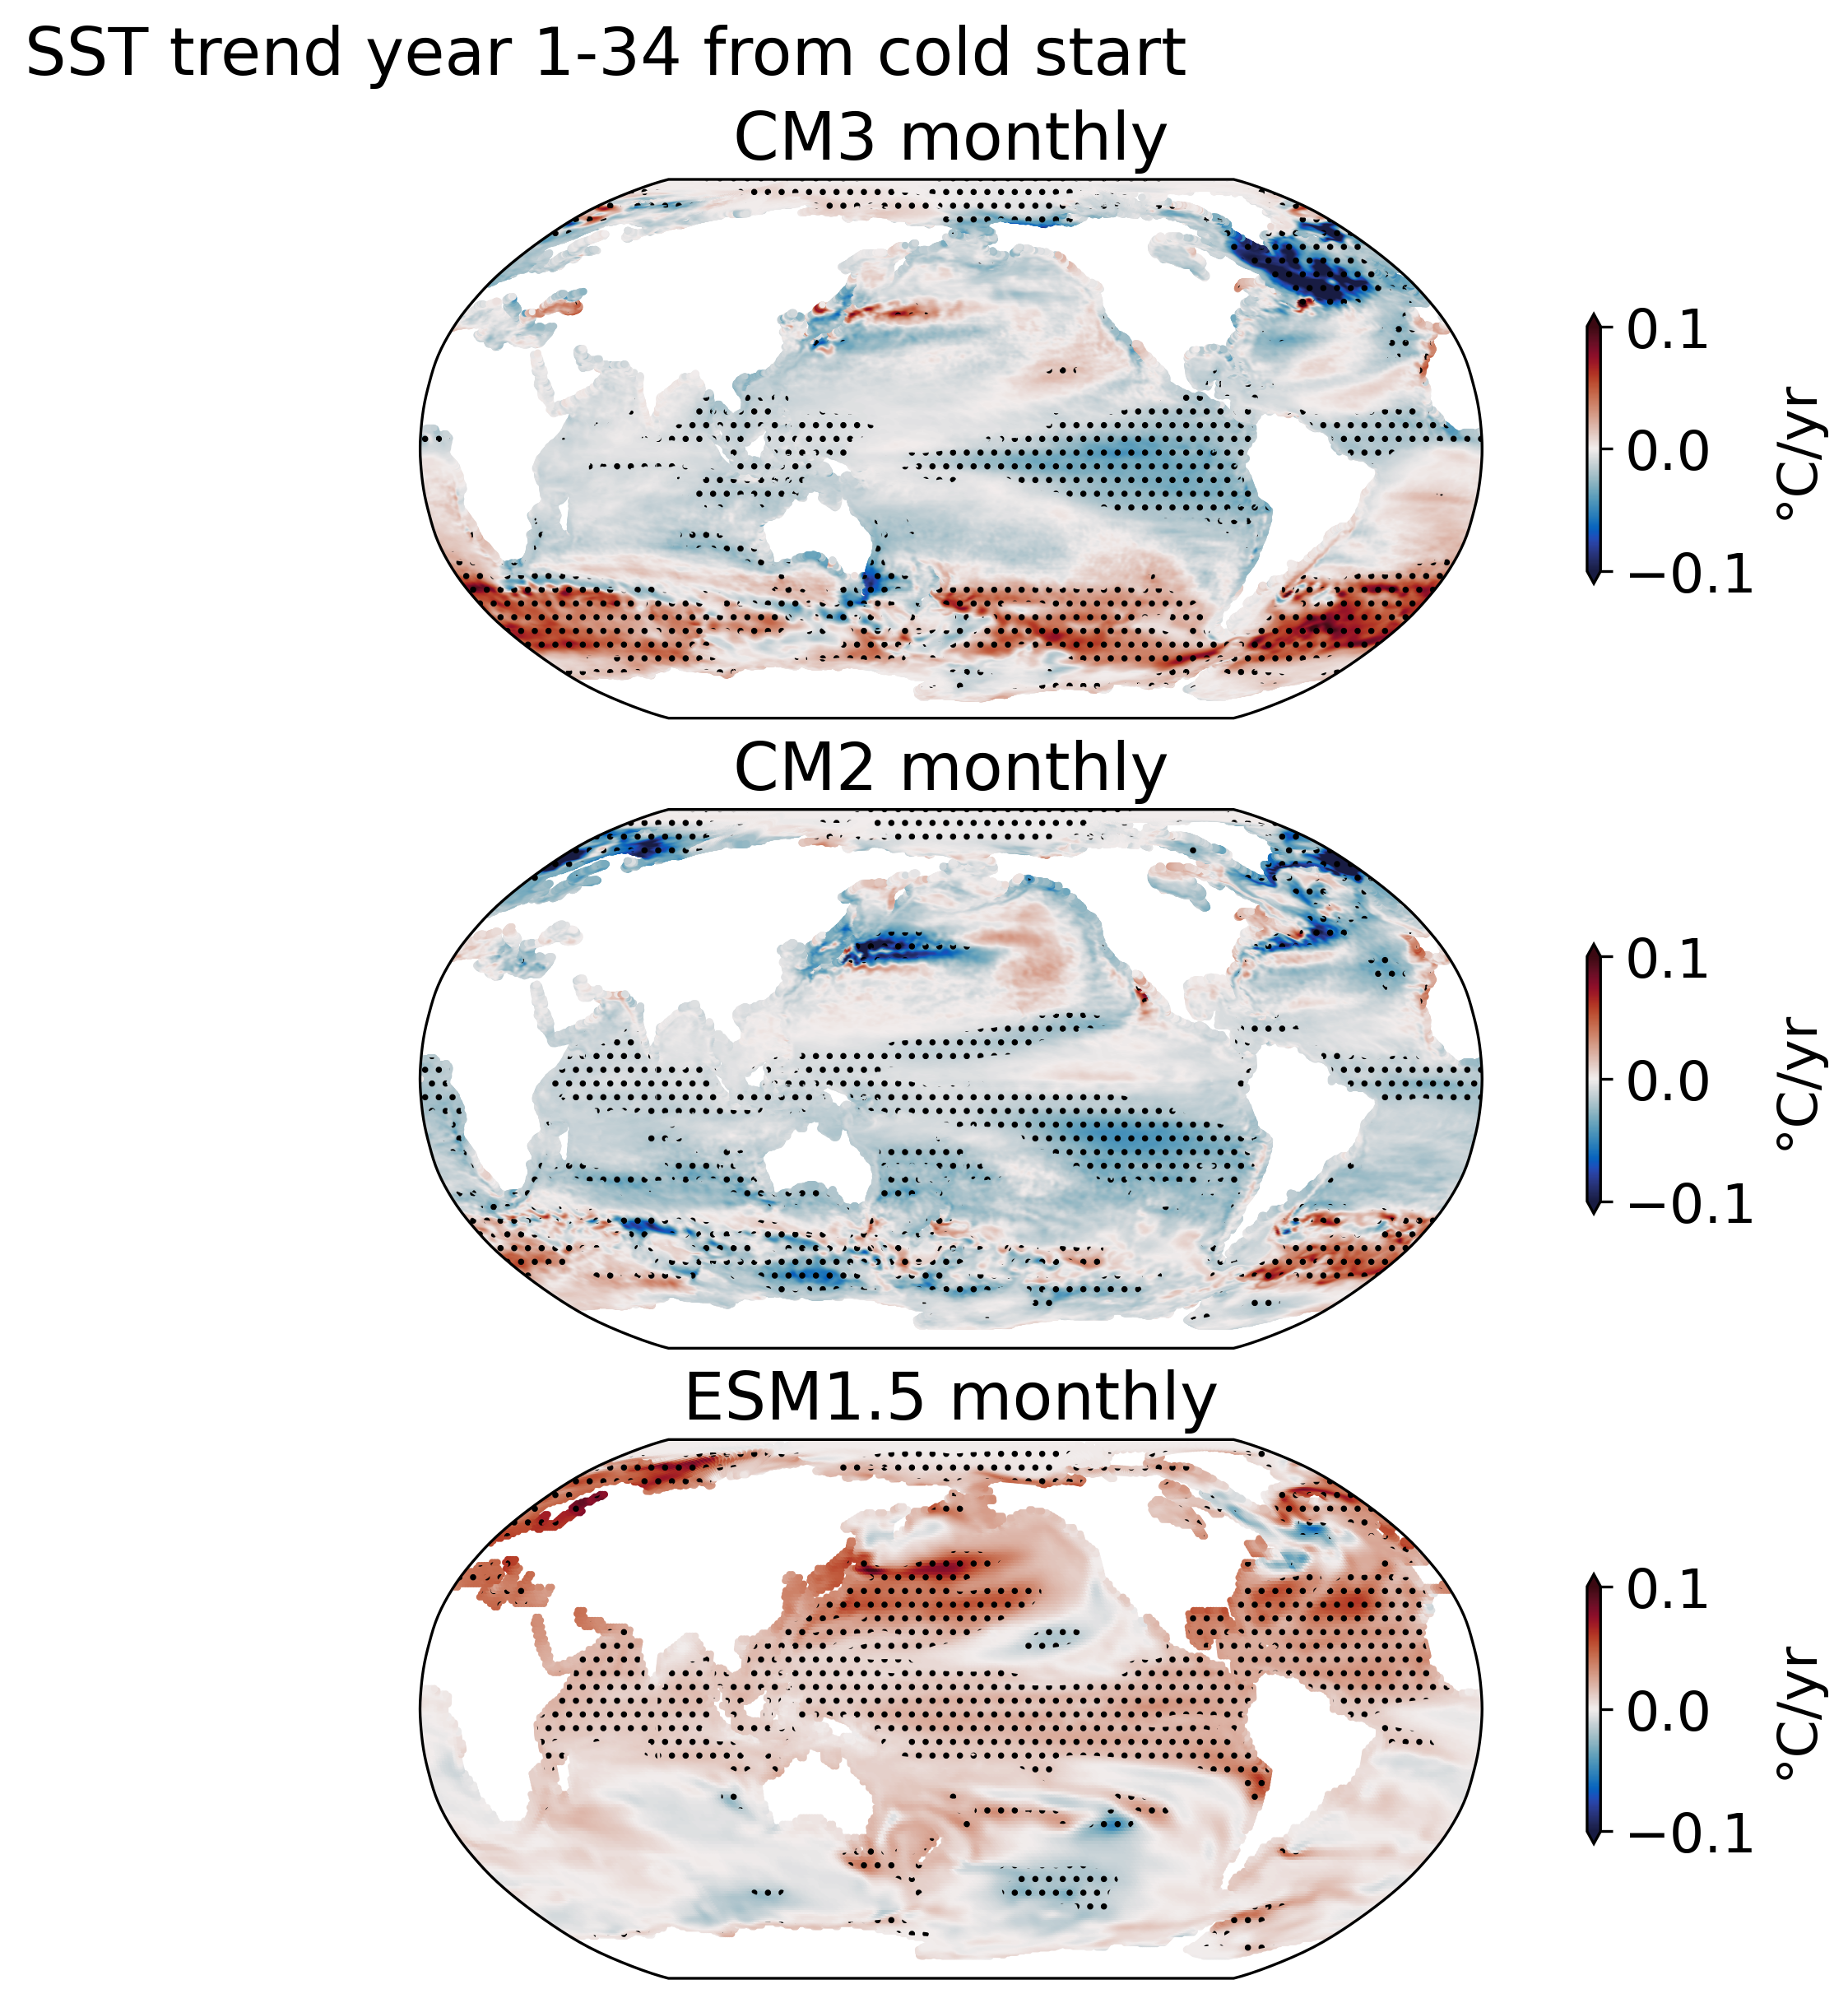

In [87]:
fig, ax = plt.subplots(3,1,figsize = (10,8), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)},constrained_layout=True)
plotting_trend(sst_trend_cm3_monthly, p_value_cm3_monthly, ax[0], 'CM3 monthly')
plotting_trend(sst_trend_cm2_monthly, p_value_cm2_monthly, ax[1], 'CM2 monthly')
plotting_trend(sst_trend_esm_monthly, p_value_esm_monthly, ax[2], 'ESM1.5 monthly')
plt.suptitle('SST trend year 1-34 from cold start')
#plt.tight_layout()
plt.rcParams.update({'font.size': 16})


In [57]:
sst_cm3 # checking xh are the same range (-280,80) as in om2?

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 408, yh: 1142, xh: 1440, nv: 2)
Coordinates:
  * time        (time) datetime64[ns] 3kB 1981-01-16T12:00:00 ... 2014-12-16T...
  * nv          (nv) float64 16B 1.0 2.0
  * yh          (yh) float64 9kB -80.94 -80.87 -80.81 ... 89.74 89.84 89.95
  * xh          (xh) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Data variables:
    tos         (time, yh, xh) float32 3GB dask.array<chunksize=(408, 1142, 60), meta=np.ndarray>
    average_DT  (time) timedelta64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    average_T1  (time) datetime64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    average_T2  (time) datetime64[ns] 3kB dask.array<chunksize=(408,), meta=np.ndarray>
    time_bnds   (time, nv) datetime64[ns] 7kB dask.array<chunksize=(408, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: access-cm3
    associated_files:  areacello: access-cm3.mom6.h.static.nc
    grid_type:         regular
    grid_tile:         N/A

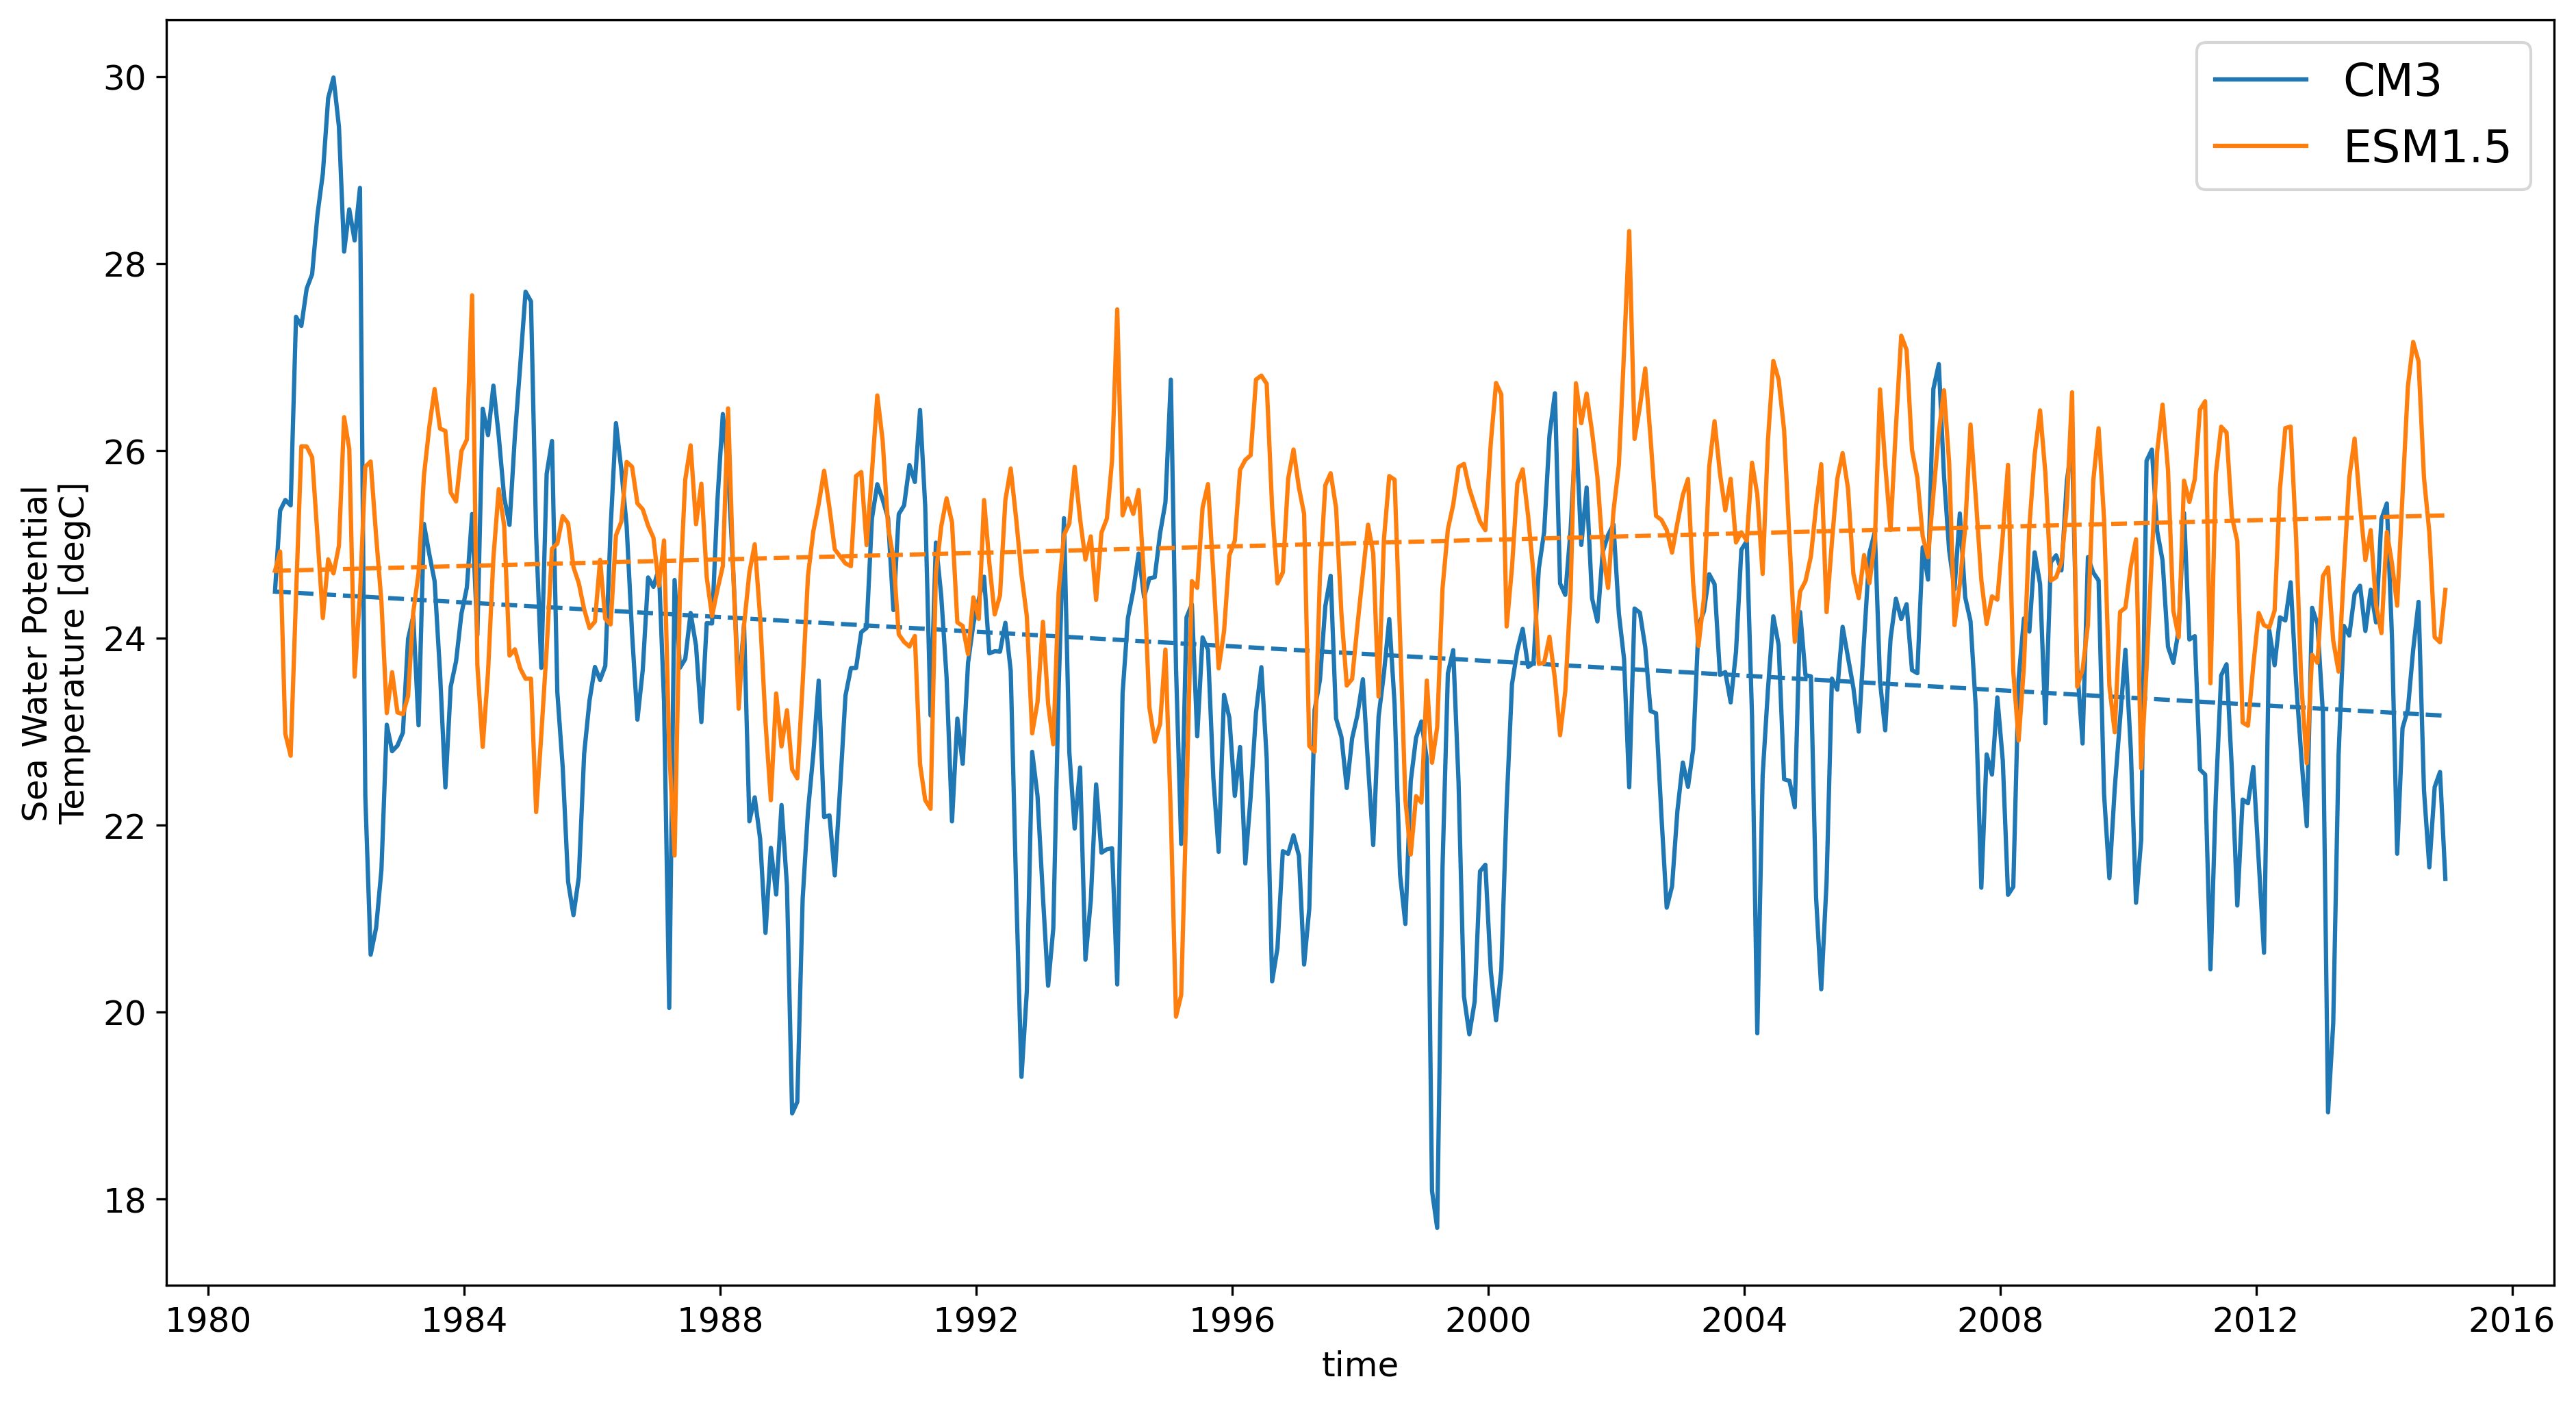

In [56]:
# over EP region (cooling in CM3)
loc_x, loc_y = -130,0
sst_esm_loc = esm_tos_monthly.sel(xt_ocean = loc_x,yt_ocean = loc_y, method = 'nearest')
sst_cm3_loc = sst_cm3.sel(xh = loc_x,yh =loc_y, method = 'nearest')

linear_esm = sst_trend_esm_monthly.sel(xt_ocean = loc_x,yt_ocean = loc_y, method = 'nearest').values * np.arange(0,34,1/12) 
linear_cm3 = sst_trend_cm3_monthly.sel(xh = loc_x,yh = loc_y, method = 'nearest').values * np.arange(0,34,1/12) 

plt.figure(figsize=(15,8))
sst_cm3_loc.tos.plot(label = 'CM3')
plt.plot(sst_cm3.time.isel(time = range(len(linear_cm3))), linear_cm3 + sst_cm3_loc.isel(time = 0).tos.values ,linestyle = 'dashed', color = 'C0')
sst_esm_loc.thetao.plot(label = 'ESM1.5')
plt.plot(esm_tos_monthly.time, linear_esm + sst_esm_loc.isel(time = 0).thetao.values\
         ,linestyle = 'dashed', color = 'C1')
plt.rcParams.update({'font.size': 16})
plt.title('')
plt.legend()

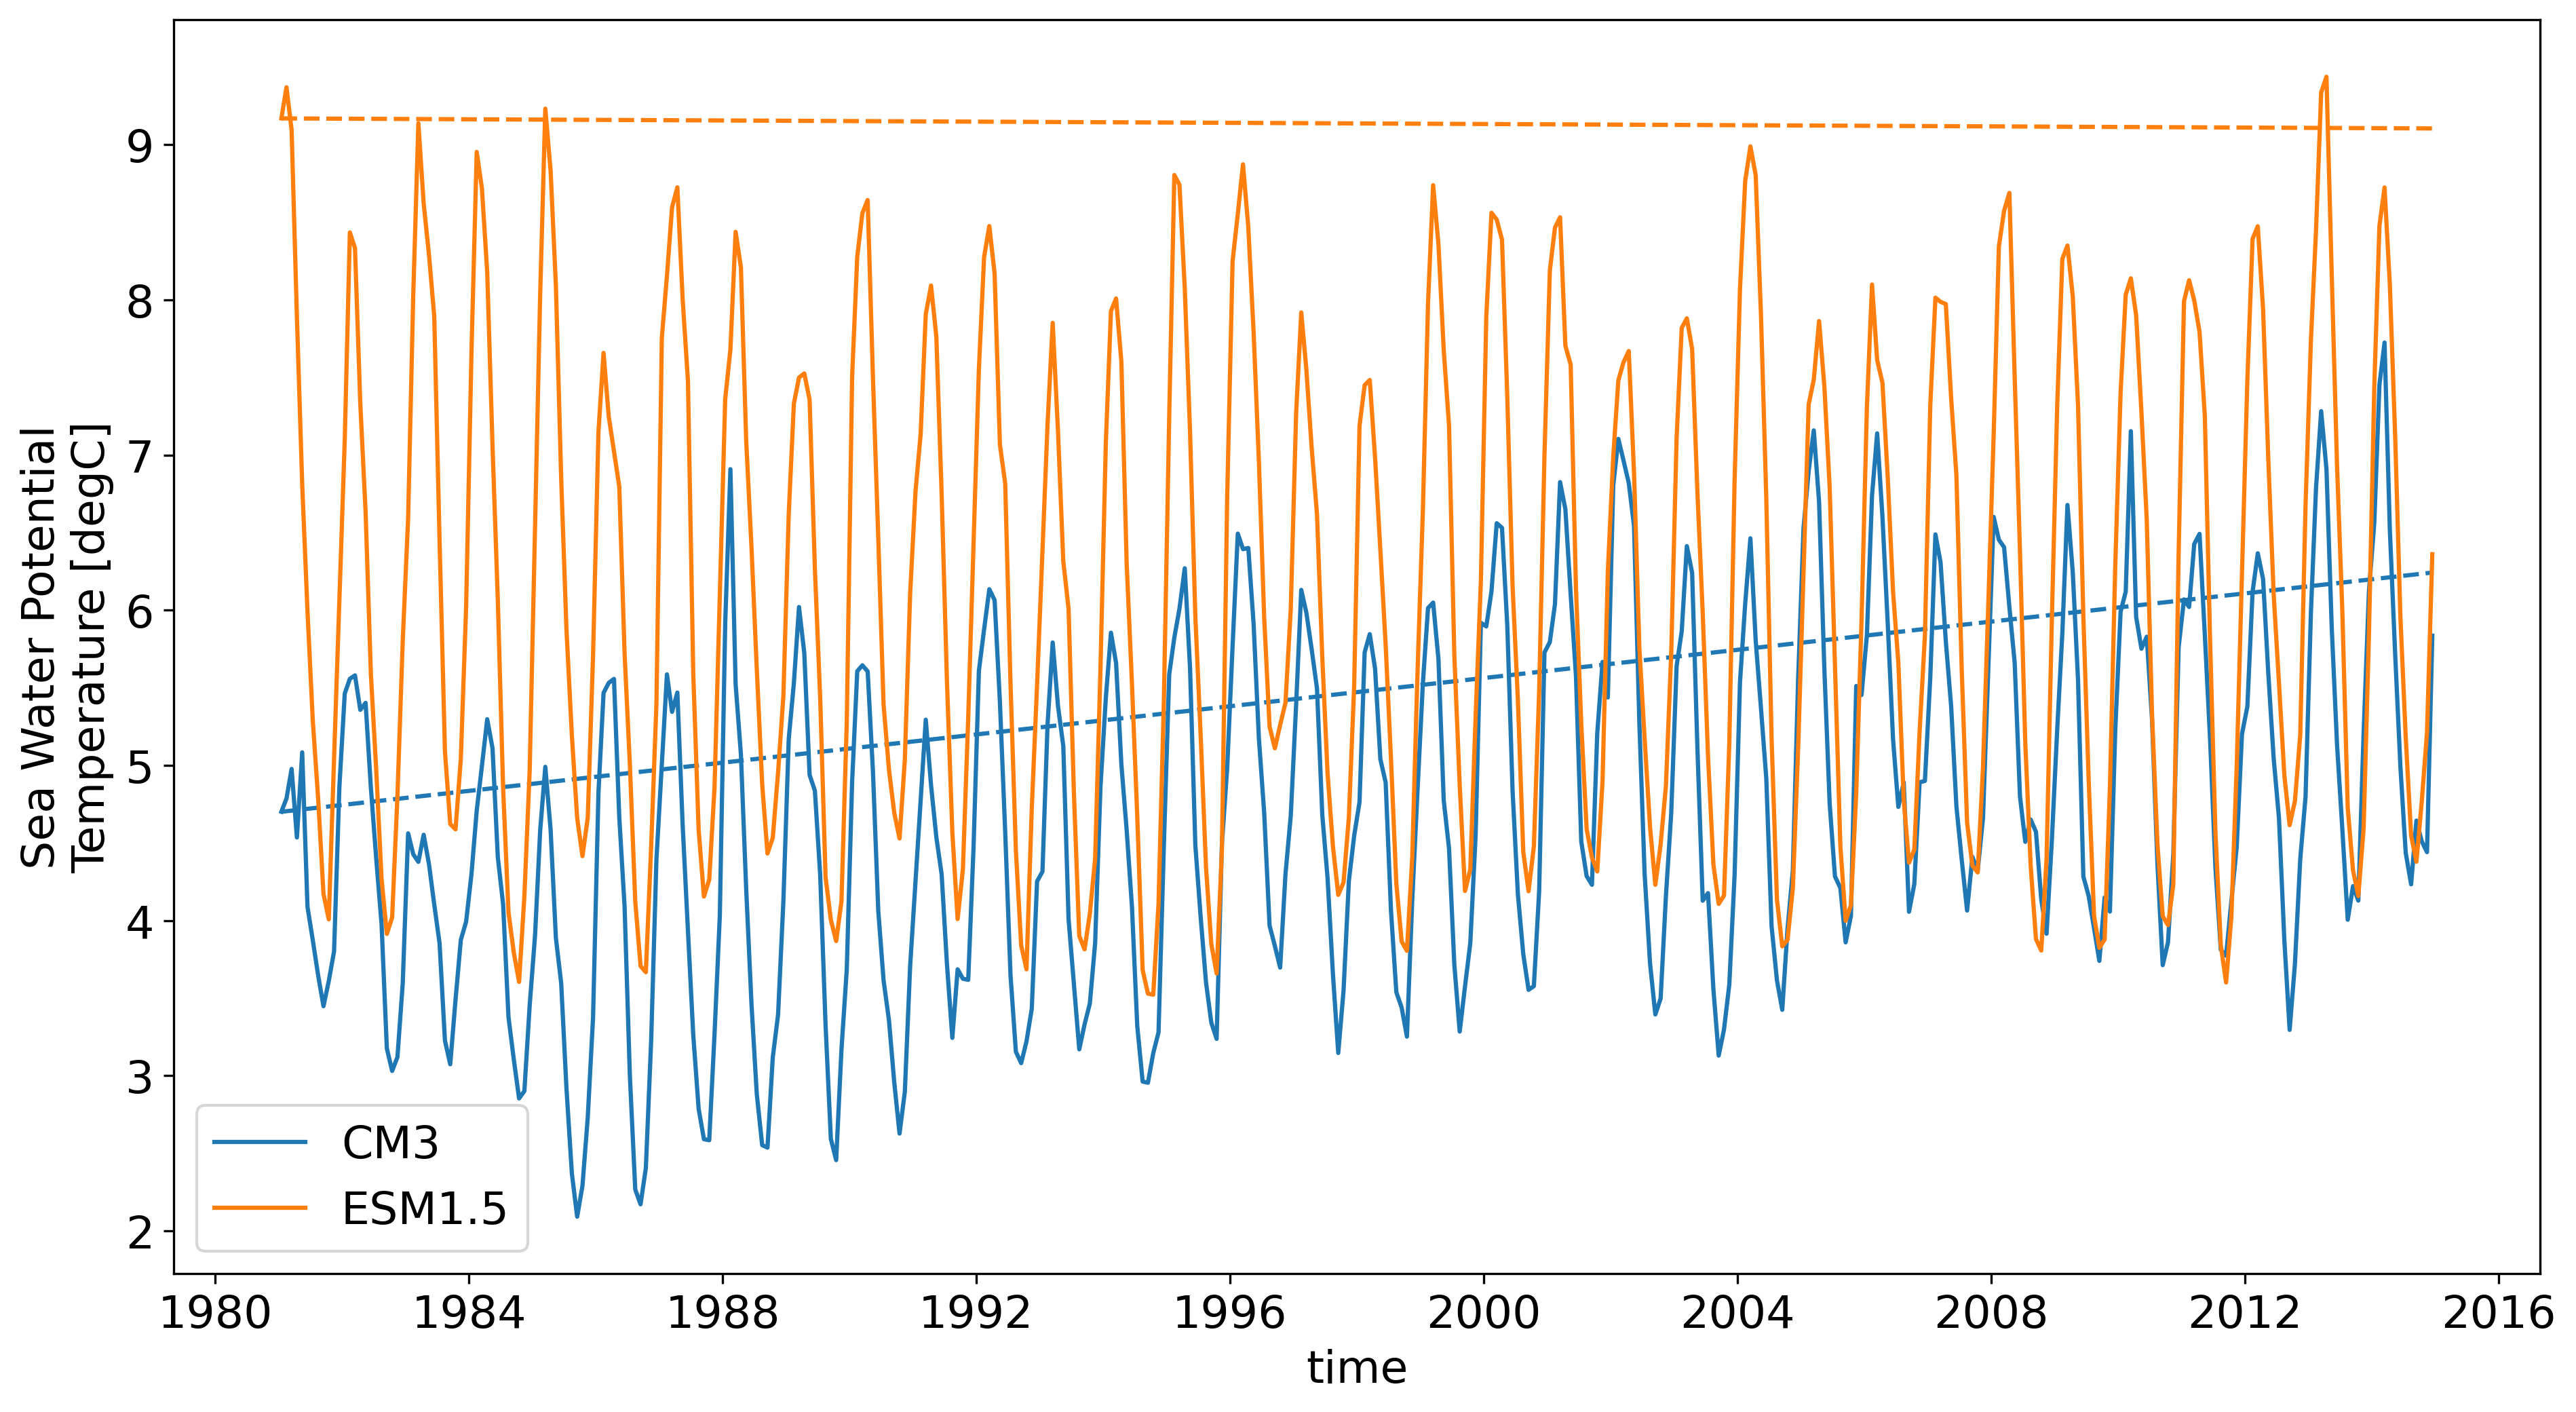

In [59]:
# over southern ocean region (warming in CM3)
loc_x, loc_y = 0,-50
sst_esm_loc = esm_tos_monthly.sel(xt_ocean = loc_x,yt_ocean = loc_y, method = 'nearest')
sst_cm3_loc = sst_cm3.sel(xh = loc_x,yh =loc_y, method = 'nearest')

linear_esm = sst_trend_esm_monthly.sel(xt_ocean = loc_x,yt_ocean = loc_y, method = 'nearest').values * np.arange(0,34,1/12) 
linear_cm3 = sst_trend_cm3_monthly.sel(xh = loc_x,yh = loc_y, method = 'nearest').values * np.arange(0,34,1/12) 

plt.figure(figsize=(15,8))
sst_cm3_loc.tos.plot(label = 'CM3')
plt.plot(sst_cm3.time.isel(time = range(len(linear_cm3))), linear_cm3 + sst_cm3_loc.isel(time = 0).tos.values ,linestyle = 'dashed', color = 'C0')
sst_esm_loc.thetao.plot(label = 'ESM1.5')
plt.plot(esm_tos_monthly.time, linear_esm + sst_esm_loc.isel(time = 0).thetao.values\
         ,linestyle = 'dashed', color = 'C1')
plt.rcParams.update({'font.size': 16})
plt.title('')
plt.legend()

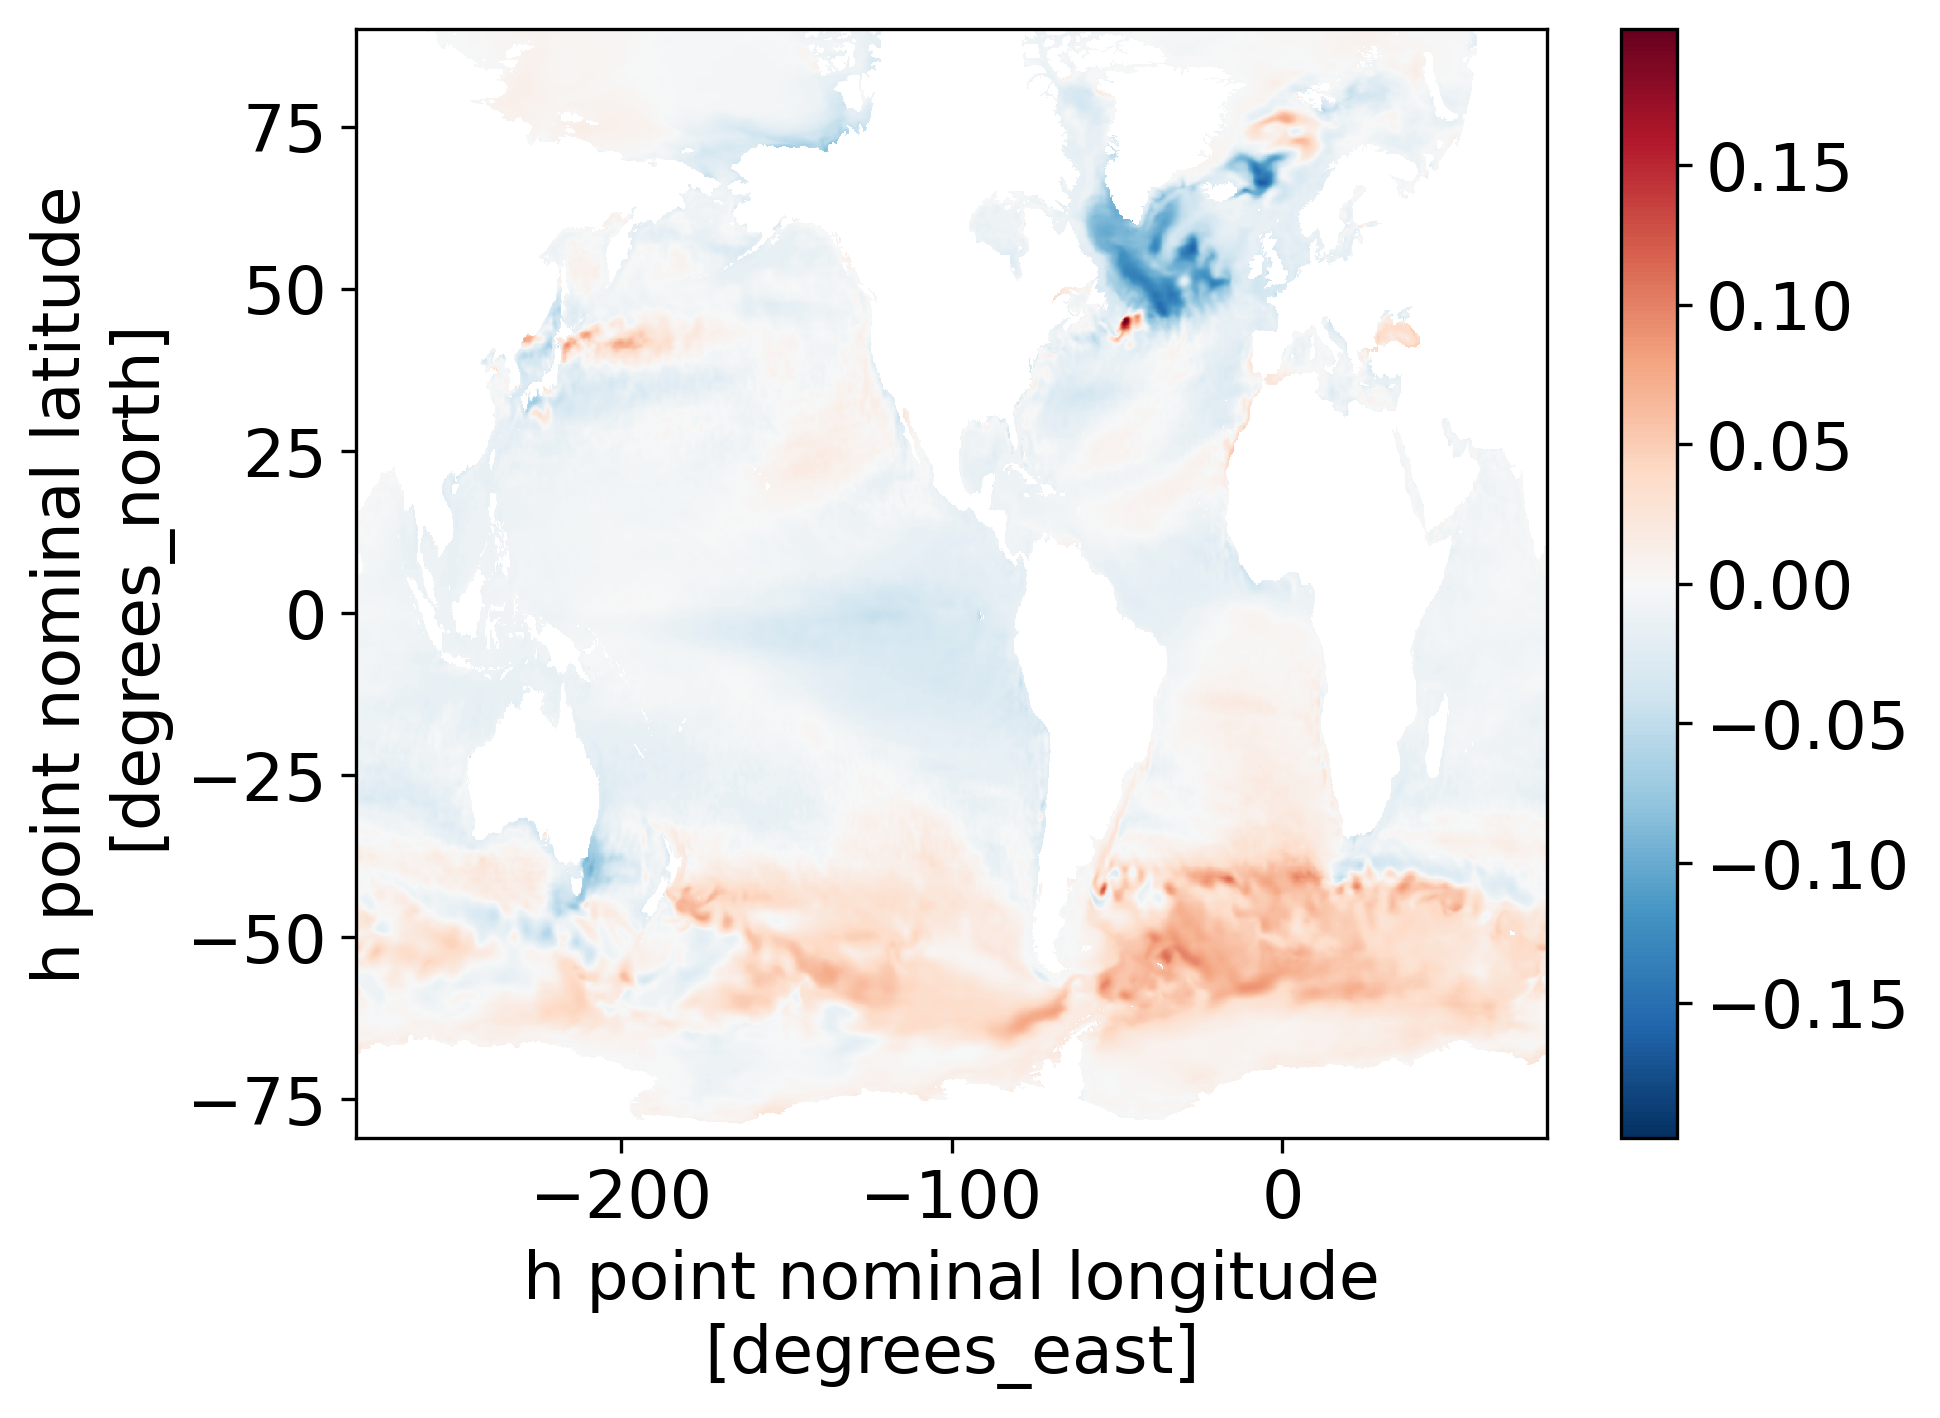

In [58]:
sst_trend_cm3_monthly.plot()